In [1]:
import sys
import os

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

## Indlæs data

In [7]:
# Tilføj sti
# sys.path.append(os.path.abspath('..'))

# Importer samlet_df fra dataloader
from dataloader import samlet_df
df = samlet_df

## Clustering

In [8]:
cluster_df = df[df['Dage i cirkulation'] > 0].copy()

# Vælg features til clustering
features = ['Total antal vask', 'Dage i cirkulation']
X = cluster_df[features]

# Lav en 'Vask-intensitet' feature 
X['Vask_intensitet'] = X['Total antal vask'] / X['Dage i cirkulation']

# Skalering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# Vi laver 4 clusters
# f.eks. "Nyt tøj", "Slidt tøj", "Høj-intensitet", "Glemt tøj"
kmeans = KMeans(n_clusters=4, random_state=42, n_init=100)
cluster_df['Cluster'] = kmeans.fit_predict(X_scaled)

# Se median for hvert cluster
print("Median: \nKendetegn for de 4 grupper:")
print(cluster_df.groupby('Cluster')[['Total antal vask', 'Dage i cirkulation']].median())

# Se gennemsnittet for hvert cluster
print("\nGennemsnit: \nKendetegn for de 4 grupper:")
print(cluster_df.groupby('Cluster')[['Total antal vask', 'Dage i cirkulation']].mean())

Median: 
Kendetegn for de 4 grupper:
         Total antal vask  Dage i cirkulation
Cluster                                      
0                     5.0               476.0
1                    93.0              1906.0
2                    37.0               748.0
3                    19.0              1943.0

Gennemsnit: 
Kendetegn for de 4 grupper:
         Total antal vask  Dage i cirkulation
Cluster                                      
0                7.637728          550.323902
1               99.032645         2035.492648
2               37.104552          738.495927
3               22.887194         2223.428520


### Visualisering

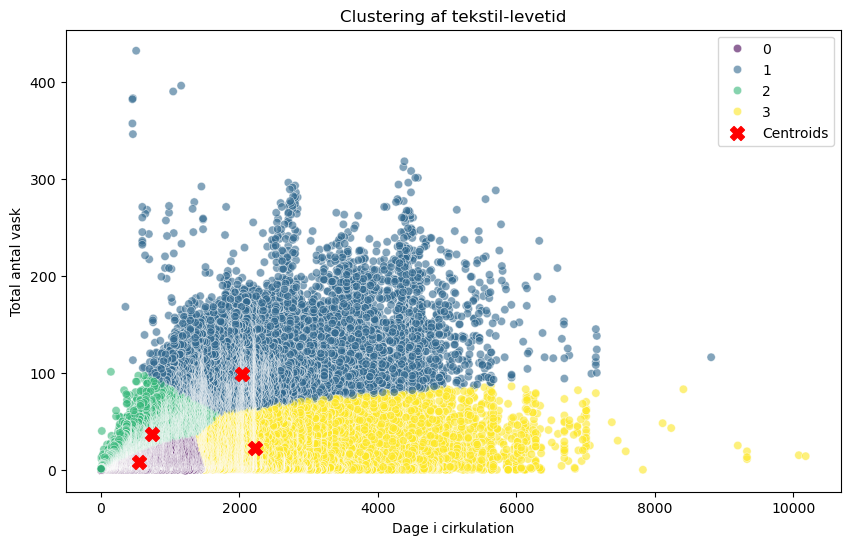

In [10]:
# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cluster_df, x='Dage i cirkulation', y='Total antal vask', 
                hue='Cluster', palette='viridis', alpha=0.6)
plt.title('Clustering af tekstil-levetid')

# Gennemsnit for hver cluster
centers = kmeans.cluster_centers_
centers_unscaled = scaler.inverse_transform(centers)
plt.scatter(centers_unscaled[:, 1], centers_unscaled[:, 0], c='red', s=100, marker='X', label='Centroids')

plt.legend()
plt.show()

### Fortolkning

Cluster 0: Forholdsvis lav alder (550 dage) og meget få vask (ca. 7-8). Det er tøj, der enten er nyt eller har ligget på lager det meste af tiden.

Cluster 1: Den mest effektive gruppe. De har kørt i ca. 5,5 år (2035 dage) og er blevet vasket næsten 100 gange.

Cluster 2: De er kun lidt ældre end Cluster 0 (738 dage), men de er blevet vasket næsten 5 gange så meget (37 vask). Det er tøj i aktiv, hård drift.

Cluster 3: Er næsten lige så gamle som Cluster 1 (2223 dage), men er kun blevet vasket 22 gange. Det betyder, at de i gennemsnit kun vaskes ca. 3-4 gange om året.

Sammenlign Cluster 1 og 3: Begge grupper er over 5,5 år gamle. Men Cluster 1 har overlevet 99 vaske, mens Cluster 3 kun har haft 22. Hvorfor kasserer man tøj i Cluster 3? Er det fordi de er blevet "for gamle" (møre i stoffet), eller er det fordi de er gået af mode (Udgået Model)?

### Optimalt antal

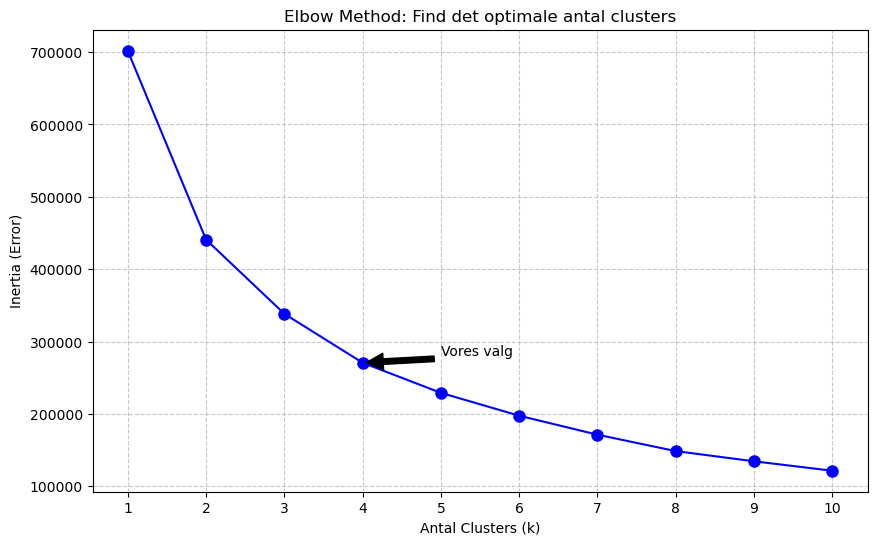

In [11]:
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# 4. Plot Elbow-kurven
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bo-', markersize=8)
plt.xlabel('Antal Clusters (k)')
plt.ylabel('Inertia (Error)')
plt.title('Elbow Method: Find det optimale antal clusters')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.7)

# Markér den "albue" du har valgt (f.eks. ved 4)
plt.annotate('Vores valg', xy=(4, inertia[3]), xytext=(5, inertia[3] + 10000),
    arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

In [12]:
for k in K_range:
    print(f"{k} clusters giver Inertia: {inertia[k-1]:.2f}")

1 clusters giver Inertia: 701946.00
2 clusters giver Inertia: 440917.19
3 clusters giver Inertia: 338387.44
4 clusters giver Inertia: 270783.78
5 clusters giver Inertia: 229130.91
6 clusters giver Inertia: 197555.03
7 clusters giver Inertia: 171303.12
8 clusters giver Inertia: 148635.83
9 clusters giver Inertia: 134527.37
10 clusters giver Inertia: 121521.41
